In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Se o arquivo estiver com separador ; (muito comum em CSVs brasileiros), usar o "sep"
#se aparecer erro de acentuação/codificação, usar enconding=latin1
url = "https://raw.githubusercontent.com/dani-barbosa/HACKHATON_ADA_DADOS_GP1/main/operacoes_financiamento_op.csv"
df = pd.read_csv(
    url,
    sep=';',
    encoding='latin1')


In [4]:
df.shape

(23419, 34)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23419 entries, 0 to 23418
Data columns (total 34 columns):
 #   Column                                      Non-Null Count  Dtype 
---  ------                                      --------------  ----- 
 0   cliente                                     23419 non-null  object
 1   cnpj                                        23419 non-null  object
 2   descricao_do_projeto                        23419 non-null  object
 3   uf                                          23419 non-null  object
 4   municipio                                   23419 non-null  object
 5   municipio_codigo                            23419 non-null  int64 
 6   numero_do_contrato                          23419 non-null  int64 
 7   data_da_contratacao                         23419 non-null  object
 8   valor_contratado_reais                      23419 non-null  object
 9   valor_desembolsado_reais                    23419 non-null  object
 10  fonte_de_recurso_desem

In [6]:
df.dtypes


,0
cliente,object
cnpj,object
descricao_do_projeto,object
uf,object
municipio,object
municipio_codigo,int64
numero_do_contrato,int64
data_da_contratacao,object
valor_contratado_reais,object
valor_desembolsado_reais,object


In [7]:
df.head()



,cliente,cnpj,descricao_do_projeto,uf,municipio,municipio_codigo,numero_do_contrato,data_da_contratacao,valor_contratado_reais,valor_desembolsado_reais,...,subsetor_cnae_nome,setor_bndes,subsetor_bndes,porte_do_cliente,natureza_do_cliente,instituicao_financeira_credenciada,cnpj_da_instituicao_financeira_credenciada,tipo_de_garantia,tipo_de_excepcionalidade,situacao_do_contrato
0,MUNICIPIO DE RIBEIRAO PRETO,56.024.581/0001-56,PROGRAMA DE MODERNIZACAO DA ADMINISTRACAO TRIB...,SP,RIBEIRAO PRETO,3543402,1247021,2002-01-02,"9090000,0","9007445,1",...,ADMINISTRACAO PUBLICA EM GERAL ...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,GRANDE,ADMINISTRAÇÃO PÚBLICA DIRETA - GOVERNO MUNICIPAL,----------,----------,"OUTRA, DE NATUREZA ESPECÍFICA OU MISTA",----------,LIQUIDADO
1,INSTITUTO DE DESENVOLVIMENTO SUSTENTAVEL DO BA...,02.275.306/0001-86,PROJETO DIREITO E CIDADANIA; PROJETO DEMONSTRA...,BA,ITUBERA,2917300,1247221,2002-01-03,"706600,0","745030,36",...,ATIV ATENCAO A SAUDE HUMANA INTEGR C/ASSIST SO...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,MICRO,PRIVADA,----------,----------,NÃO SE APLICA,----------,LIQUIDADO
2,INSTITUTO DE DESENVOLVIMENTO SUSTENTAVEL DO BA...,02.275.306/0001-86,PROJETO DIREITO E CIDADANIA; PROJETO DEMONSTRA...,BA,ITUBERA,2917300,1247221,2002-01-03,"75691,59","78500,0",...,ATIV ATENCAO A SAUDE HUMANA INTEGR C/ASSIST SO...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,MICRO,PRIVADA,----------,----------,NÃO SE APLICA,----------,LIQUIDADO
3,INSTITUTO DE DESENVOLVIMENTO SUSTENTAVEL DO BA...,02.275.306/0001-86,PROJETO DIREITO E CIDADANIA; PROJETO DEMONSTRA...,BA,ITUBERA,2917300,1247221,2002-01-03,"603981,41","653834,69",...,ATIV ATENCAO A SAUDE HUMANA INTEGR C/ASSIST SO...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,MICRO,PRIVADA,----------,----------,NÃO SE APLICA,----------,LIQUIDADO
4,ACEF S/A,46.722.831/0001-78,AQUISICAO DE EQUIPAMENTOS NACIONAIS E MOBILIAR...,SP,FRANCA,3516200,1255421,2002-01-09,"340201,0","340189,32",...,EDUCACAO SUPERIOR - GRADUACAO ...,COMERCIO/SERVICOS,COMÉRCIO E SERVIÇOS,GRANDE,PRIVADA,BANCO BRADESCO S.A.,60746948000112,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO


In [8]:
#convertendo colunas string em valor

def limpar_monetario(col):
    return (
        col.astype(str)
           .str.replace(".", "", regex=False)   # remove milhar
           .str.replace(",", ".", regex=False)  # corrige decimal
    )

for col in ["valor_contratado_reais", "valor_desembolsado_reais"]:
    df[col] = limpar_monetario(df[col])

for col in ["valor_contratado_reais", "valor_desembolsado_reais"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["juros"] = pd.to_numeric(df["juros"], errors="coerce")
df["prazo_carencia_meses"] = pd.to_numeric(df["prazo_carencia_meses"], errors="coerce")
df["prazo_amortizacao_meses"] = pd.to_numeric(df["prazo_amortizacao_meses"], errors="coerce")

df["data_da_contratacao"] = pd.to_datetime(
    df["data_da_contratacao"],
    errors="coerce"
)


In [9]:
df.dtypes

,0
cliente,object
cnpj,object
descricao_do_projeto,object
uf,object
municipio,object
municipio_codigo,int64
numero_do_contrato,int64
data_da_contratacao,datetime64[ns]
valor_contratado_reais,float64
valor_desembolsado_reais,float64


In [10]:
#Identificando se há campo nulo
df.isna().sum()

,0
cliente,0
cnpj,0
descricao_do_projeto,0
uf,0
municipio,0
municipio_codigo,0
numero_do_contrato,0
data_da_contratacao,0
valor_contratado_reais,0
valor_desembolsado_reais,0


In [11]:

# percentual de nulos
(df.isna().mean() * 100).sort_values(ascending=False)


,0
juros,100.0
cliente,0.0
cnpj,0.0
descricao_do_projeto,0.0
municipio,0.0
uf,0.0
numero_do_contrato,0.0
data_da_contratacao,0.0
valor_contratado_reais,0.0
municipio_codigo,0.0


In [12]:

df["juros"] = (
    df["juros"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

# preencher juros nulos com 0 (sem custo financeiro explícito)
df["juros"] = df["juros"].fillna(0)



In [13]:
df_desc = df.describe()

df_desc

,municipio_codigo,numero_do_contrato,data_da_contratacao,valor_contratado_reais,valor_desembolsado_reais,prazo_carencia_meses,prazo_amortizacao_meses
count,2.341900e+04,2.341900e+04,23419,2.341900e+04,2.341900e+04,23419.000000,23419.000000
mean,3.526621e+06,1.352386e+07,2013-09-02 11:08:19.133182720,5.212627e+07,4.065274e+07,21.029976,93.029250
min,0.000000e+00,2.027110e+05,2002-01-02 00:00:00,5.500000e-01,0.000000e+00,0.000000,0.000000
25%,2.208007e+06,8.208331e+06,2009-02-26 00:00:00,2.199696e+06,1.250371e+06,12.000000,54.000000
50%,3.502101e+06,1.220998e+07,2012-10-23 00:00:00,9.479830e+06,6.730461e+06,18.000000,72.000000
75%,4.209102e+06,1.720333e+07,2017-09-05 00:00:00,3.255638e+07,2.531752e+07,26.000000,144.000000
max,9.999999e+06,9.926332e+07,2026-03-31 00:00:00,9.889998e+09,9.889998e+09,259.000000,399.000000
std,2.825363e+06,8.442479e+06,NaN,2.164378e+08,1.843292e+08,16.336383,64.797213


In [14]:
# remover registros sem valor financeiro (inviáveis para risco)
df = df.dropna(subset=["valor_contratado_reais"])


In [15]:
#Criando variáveis de risco

df["diferenca_valor"] = (
    df["valor_desembolsado_reais"] - df["valor_contratado_reais"]
)

df["contrato_ativo"] = np.where(
    df["situacao_do_contrato"] == "ATIVO", 1, 0
)

df["contrato_financeiro"] = (
    df["valor_contratado_reais"] *
    df["prazo_amortizacao_meses"]
)


In [16]:
df_filtrado = df[['uf', 'valor_contratado_reais', 'forma_de_apoio', 'porte_do_cliente']]

df_filtrado.head()

,uf,valor_contratado_reais,forma_de_apoio,porte_do_cliente
0,SP,9090000.00,DIRETA,GRANDE
1,BA,706600.00,DIRETA,MICRO
2,BA,75691.59,DIRETA,MICRO
3,BA,603981.41,DIRETA,MICRO
4,SP,340201.00,INDIRETA,GRANDE


In [17]:
df[df['uf'] == 'IE']

,cliente,cnpj,descricao_do_projeto,uf,municipio,municipio_codigo,numero_do_contrato,data_da_contratacao,valor_contratado_reais,valor_desembolsado_reais,...,porte_do_cliente,natureza_do_cliente,instituicao_financeira_credenciada,cnpj_da_instituicao_financeira_credenciada,tipo_de_garantia,tipo_de_excepcionalidade,situacao_do_contrato,diferenca_valor,contrato_ativo,contrato_financeiro
183,LOJAS AMERICANAS S.A.,33.014.556/0001-96,"ABERTURA DE OITO LOJAS, REFORMA DE QUINZE LOJA...",IE,SEM MUNICÍPIO,0,1255111,2002-03-21,4.040770e+06,4058888.48,...,GRANDE,PRIVADA,ITAU UNIBANCO S.A.,60701190000104,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO,1.811848e+04,0,2.424462e+08
184,LOJAS AMERICANAS S.A.,33.014.556/0001-96,"ABERTURA DE OITO LOJAS, REFORMA DE QUINZE LOJA...",IE,SEM MUNICÍPIO,0,1255111,2002-03-21,5.067432e+06,5090153.94,...,GRANDE,PRIVADA,ITAU UNIBANCO S.A.,60701190000104,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO,2.272194e+04,0,3.040459e+08
185,LOJAS AMERICANAS S.A.,33.014.556/0001-96,"ABERTURA DE OITO LOJAS, REFORMA DE QUINZE LOJA...",IE,SEM MUNICÍPIO,0,1255111,2002-03-21,3.166036e+06,3180232.24,...,GRANDE,PRIVADA,BANCO MODAL S.A.,30723886000162,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO,1.419624e+04,0,1.899622e+08
186,LOJAS AMERICANAS S.A.,33.014.556/0001-96,"ABERTURA DE OITO LOJAS, REFORMA DE QUINZE LOJA...",IE,SEM MUNICÍPIO,0,1255111,2002-03-21,2.534602e+06,2545966.94,...,GRANDE,PRIVADA,BANCO BRADESCO S.A.,60746948000112,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO,1.136494e+04,0,1.520761e+08
187,LOJAS AMERICANAS S.A.,33.014.556/0001-96,"ABERTURA DE OITO LOJAS, REFORMA DE QUINZE LOJA...",IE,SEM MUNICÍPIO,0,1255111,2002-03-21,1.154358e+06,1159534.04,...,GRANDE,PRIVADA,ITAU UNIBANCO S.A.,60701190000104,DEFINIDA PELO AGENTE FINANCEIRO,----------,LIQUIDADO,5.176040e+03,0,6.926148e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23377,INSTITUTO EKLOOS,11.285.430/0001-13,PROMOVER O FORTALECIMENTO INSTITUCIONAL DE ORG...,IE,SEM MUNICÍPIO,9999999,26200291,2026-03-12,1.750000e+07,0.00,...,SEM PORTE,PRIVADA,----------,----------,NÃO SE APLICA,----------,ATIVO,-1.750000e+07,1,0.000000e+00
23378,VEREDAS AGROFLORESTAL HOLDING S.A.,60.142.595/0001-41,IMPLANTACAO DE 2 MIL HECTARES DE SISTEMAS AGRO...,IE,SEM MUNICÍPIO,9999999,25901471,2026-03-12,2.000000e+08,0.00,...,PEQUENA,PRIVADA,----------,----------,SEM REGISTRO DE GARANTIA,----------,ATIVO,-2.000000e+08,1,3.840000e+10
23397,VOTORANTIM CIMENTOS S.A.,01.637.895/0001-32,"DIGITALIZACAO DO PROCESSO DE PESAGEM, TRATATIV...",IE,SEM MUNICÍPIO,9999999,25901841,2026-03-24,1.146100e+07,0.00,...,SEM PORTE,PRIVADA,----------,----------,SEM REGISTRO DE GARANTIA,----------,ATIVO,-1.146100e+07,1,1.100256e+09
23398,VOTORANTIM CIMENTOS S.A.,01.637.895/0001-32,"DIGITALIZACAO DO PROCESSO DE PESAGEM, TRATATIV...",IE,SEM MUNICÍPIO,9999999,25901841,2026-03-24,1.146200e+07,0.00,...,SEM PORTE,PRIVADA,----------,----------,SEM REGISTRO DE GARANTIA,----------,ATIVO,-1.146200e+07,1,1.100352e+09


In [18]:
df.replace(
    ["----------", "SEM MUNICÍPIO", ""],
    np.nan,
    inplace=True
)


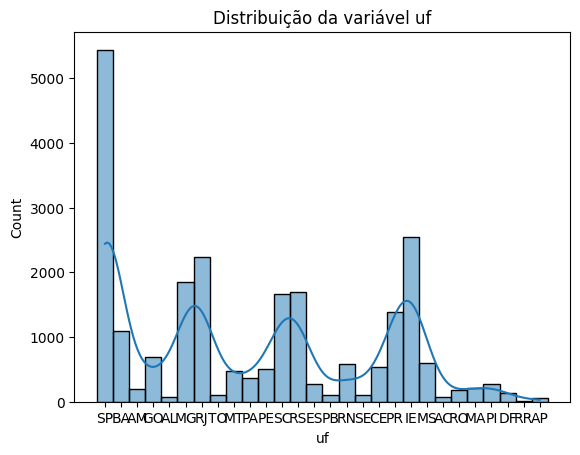

<Figure size 1200x600 with 0 Axes>

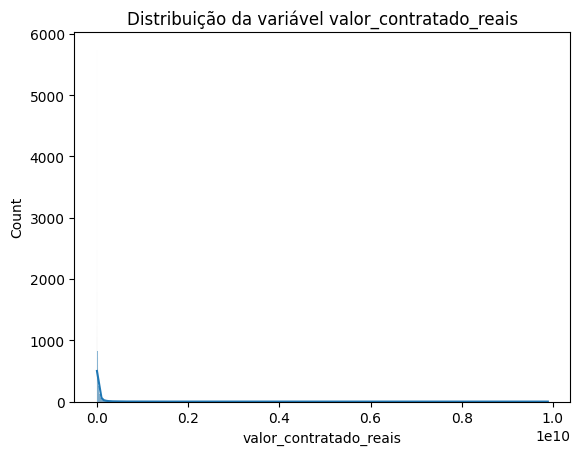

<Figure size 1200x600 with 0 Axes>

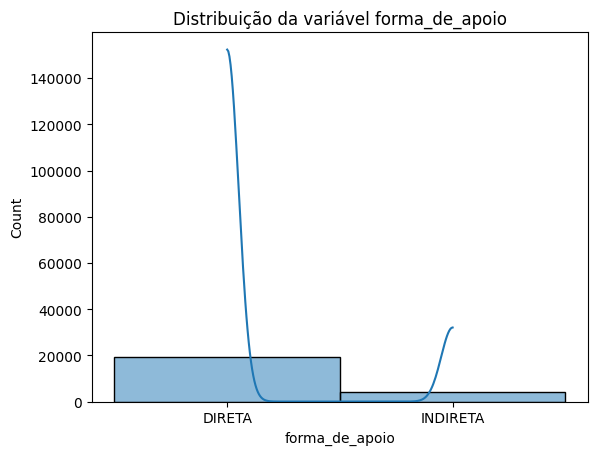

<Figure size 1200x600 with 0 Axes>

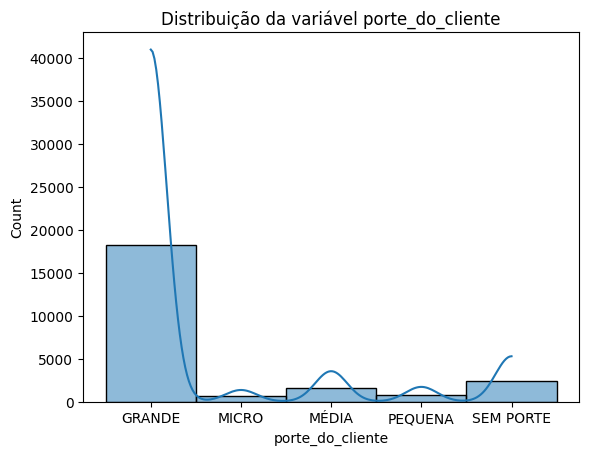

<Figure size 1200x600 with 0 Axes>

In [20]:
# visualizando distribuições com histogramas para ter intuição quanto a outliers
for col in df_filtrado:

   sns.histplot(data=df_filtrado, x=col, kde=True).set_title(f"Distribuição da variável {col}")
   plt.figure(figsize=(12,6))
   plt.show()

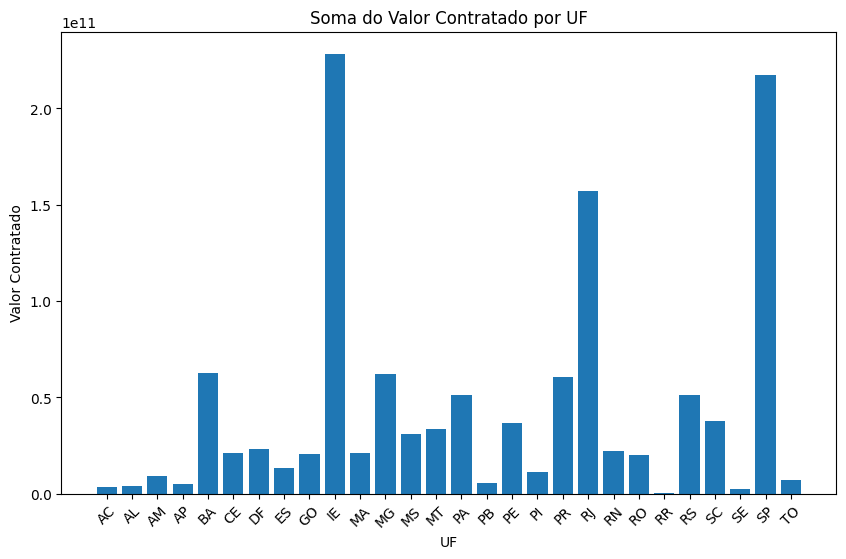

In [21]:
df_uf = (
    df.groupby('uf')['valor_contratado_reais']
    .sum()
    .reset_index()
)
plt.figure(figsize=(10,6))

plt.bar(df_uf['uf'], df_uf['valor_contratado_reais'])

plt.xlabel('UF')
plt.ylabel('Valor Contratado')
plt.title('Soma do Valor Contratado por UF')

plt.xticks(rotation=45)

plt.show()